# ex-6 — prevalence and the collapse law

Two results about the **rotation** term $\sin^2\angle(\hat w_j, e_j)$, building on ex-4.

**Part 1 — prevalence.** The tilt is driven by the limiting eigenvalues $\lambda_j = c_j\sigma_j^2$, so *prevalence* $c$ should control identifiability just as much as *volatility* $\sigma$. Tested by re-weighting $c$ alone, with $\sigma$ held fixed at the bunched k=6 values — plus a control where all $\sigma$ are equal and $c$ does all the separating.

**Part 2 — the collapse law.** Sweeping the adjacent eigenvalue ratio $r$ and the sample size $n$, the median tilt should depend on them only through one combination:

$$x \;=\; \frac{\sqrt{n}\,(r-1)}{\sqrt{r}}, \qquad \text{median}\,\sin^2\angle \;\approx\; \frac{0.455}{x^2}$$

The constant $0.455$ is not fitted — it is the median of a $\chi^2_1$ distribution ($0.6745^2$), which is what the squared off-diagonal noise term converges to.

## Setup

In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path.cwd()
OUT_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR.mkdir(exist_ok=True)
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt

SEED = 20260719
Q_LEVELS = [0.50, 0.80, 0.95]
INK, BLUE, RED, GREEN = "#1a1a2e", "#2563eb", "#dc2626", "#059669"
print("ready")

ready


### The batched rotation helper

This is exactly the loop body from ex-4, vectorised over replications so the k=6 and sweep cells finish in seconds. Line-by-line it maps to what you already wrote:

| ex-4 | here |
|---|---|
| `F = rng.standard_t(6, size=(n,k))/np.sqrt(1.5)*sigma` | same, with a leading `reps` axis |
| `Dhat = Chalf @ (F.T@F/n) @ Chalf` | `X = F*np.sqrt(c)` then `einsum(...)/n` — same sandwich, done by scaling columns |
| `vals, vecs = np.linalg.eigh(Dhat)` | batched `eigh` over the whole chunk at once |
| `W = vecs[:, ::-1]` | `vecs[:, :, ::-1]` (extra leading axis) |
| `sin2_angle_to_axis(W)` | `1 - np.diagonal(W**2, ...)` — the same formula inlined (safe because `eigh` returns unit-norm columns) |

In [2]:
def rotation_sin2_batch(n, sigma, c, rng, reps, dist="t6", chunk=5_000):
    """Return (reps, k) array of sin2 angle(w_j, e_j). Batched version of the ex-4 loop."""
    sigma, c = np.asarray(sigma, float), np.asarray(c, float)
    k = len(sigma)
    out = np.empty((reps, k))
    for i0 in range(0, reps, chunk):
        m = min(chunk, reps - i0)
        if dist == "t6":
            F = rng.standard_t(6, size=(m, n, k)) / np.sqrt(1.5) * sigma
        else:
            F = rng.standard_normal((m, n, k)) * sigma
        X = F * np.sqrt(c)
        Dh = np.einsum("rti,rtj->rij", X, X) / n
        _, vecs = np.linalg.eigh(Dh)
        W = vecs[:, :, ::-1]
        out[i0:i0+m] = 1.0 - np.diagonal(W ** 2, axis1=1, axis2=2)
    return out

---
## Part 1 — prevalence controls identifiability

Three calibrations. The first is k=6 as-is. The second keeps **every volatility identical** and moves only the prevalences so the eigenvalues sit on an evenly-spaced ladder. The third is the control: flat volatility, prevalence doing all the work.

In [3]:
SIGMA6    = np.array([0.16, 0.10, 0.09, 0.08, 0.06, 0.05]) 
C_BUNCHED = np.array([1.25, 1.0, 1.0, 1.0, 1.0, 1.0])        
SIGMA_FLAT = np.full(6, 0.08)                                

TARGET_RATIO = 1.82         
lam1 = C_BUNCHED[0] * SIGMA6[0] ** 2      
lam_target = lam1 / TARGET_RATIO ** np.arange(6)

c_fixed = lam_target / SIGMA6 ** 2

c_pure = lam_target / SIGMA_FLAT ** 2

CALIBS = {
    "bunched (k6)":  dict(sigma=SIGMA6,     c=C_BUNCHED),
    "prevalence-fixed":   dict(sigma=SIGMA6,     c=c_fixed),
    "pure-prevalence":    dict(sigma=SIGMA_FLAT, c=c_pure),
}
for name, cal in CALIBS.items():
    lam = cal["c"] * cal["sigma"] ** 2
    print(f"{name:20s} c={np.round(cal['c'],2)}  adjacent lambda ratios={np.round(lam[:-1]/lam[1:],2)}")

bunched (k6)         c=[1.25 1.   1.   1.   1.   1.  ]  adjacent lambda ratios=[3.2  1.23 1.27 1.78 1.44]
prevalence-fixed     c=[1.25 1.76 1.19 0.83 0.81 0.64]  adjacent lambda ratios=[1.82 1.82 1.82 1.82 1.82]
pure-prevalence      c=[5.   2.75 1.51 0.83 0.46 0.25]  adjacent lambda ratios=[1.82 1.82 1.82 1.82 1.82]


In [4]:
# checks: the two isolated ladders must have every adjacent ratio equal to TARGET_RATIO,
# and must NOT have changed SIGMA6 in the prevalence-fixed case.
for name in ["prevalence-fixed", "pure-prevalence"]:
    cal = CALIBS[name]
    lam = cal["c"] * cal["sigma"] ** 2
    assert np.allclose(lam[:-1] / lam[1:], TARGET_RATIO), f"{name}: ladder is not geometric"
assert np.array_equal(CALIBS["prevalence-fixed"]["sigma"], SIGMA6), "sigma was modified!"
assert np.allclose(CALIBS["prevalence-fixed"]["c"] * SIGMA6**2,
                   CALIBS["pure-prevalence"]["c"] * SIGMA_FLAT**2), "ladders disagree"
print("checks passed — same eigenvalues, reached two different ways")

checks passed — same eigenvalues, reached two different ways


In [5]:
N_REPS_P = 30_000
rows = []
for name, cal in CALIBS.items():
    for n in (63, 126):
        rng = np.random.default_rng([SEED, 7, n, abs(hash(name)) % 2**31])
        s = rotation_sin2_batch(n, cal["sigma"], cal["c"], rng, N_REPS_P, dist="t6")
        for j in range(6):
            qs = np.quantile(s[:, j], Q_LEVELS)
            rows.append({"calib": name, "n": n, "factor": j + 1,
                         "q50": qs[0], "q80": qs[1], "q95": qs[2]})

prev = pd.DataFrame(rows)
prev.to_csv(OUT_DIR / "ex6_prevalence.csv", index=False)
prev[prev["n"] == 63].pivot_table(index="factor", columns="calib", values="q50").round(3)

calib,bunched (k6),prevalence-fixed,pure-prevalence
factor,,,
1,0.022,0.041,0.041
2,0.290,0.102,0.101
3,0.576,0.116,0.116
4,0.405,0.120,0.118
5,0.237,0.108,0.109
6,0.112,0.044,0.045


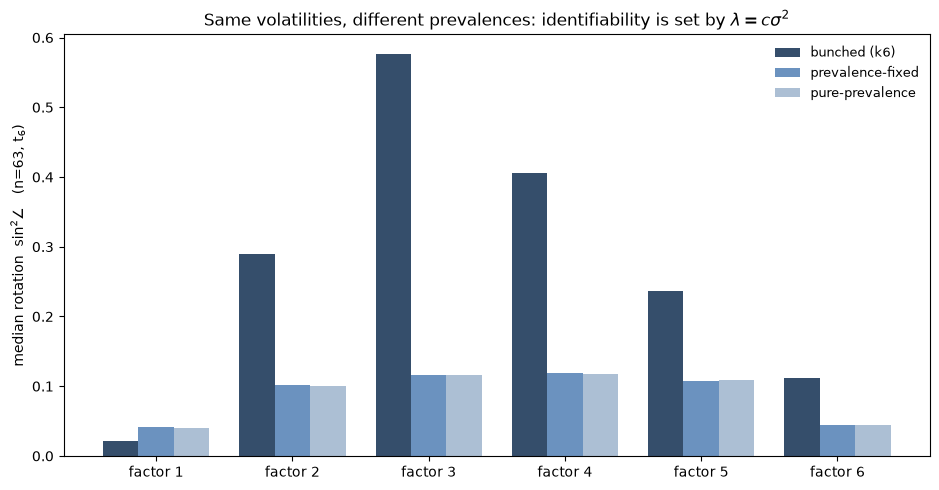

In [6]:
DARK, MID, LIGHT = "#354E6B", "#6B92BF", "#ACBFD4"

fig, ax = plt.subplots(figsize=(9.5, 5))
x = np.arange(6); w = 0.26
for i, (name, col) in enumerate(zip(CALIBS, [DARK, MID, LIGHT])):
    med = prev[(prev["calib"] == name) & (prev["n"] == 63)].sort_values("factor")["q50"]
    ax.bar(x + (i - 1) * w, med, w, color=col, label=name)
ax.set_xticks(x); ax.set_xticklabels([f"factor {j+1}" for j in range(6)])
ax.set_ylabel(r"median rotation  sin$^2\angle$   (n=63, t$_6$)")
ax.set_title(r"Same volatilities, different prevalences: identifiability is set by $\lambda=c\sigma^2$")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(OUT_DIR / "ex6_prevalence.png", dpi=200, bbox_inches="tight")
plt.show()

---
## Part 2 — the collapse law

Two factors only (the minimal system: one gap, no interference from other neighbours). Sweep the eigenvalue ratio $r$ and the sample size $n$ independently, then check whether the results depend on them only through $x=\sqrt n(r-1)/\sqrt r$.

In [7]:
R_LIST = [1.05, 1.10, 1.20, 1.35, 1.50, 1.75, 2.0, 2.5, 3.0, 4.0, 5.0]
N_LIST = [20, 63, 126, 252, 504]
LAM1, N_REPS_C = 0.032, 20_000

rows = []
for dist in ("t6", "gauss"):
    for r in R_LIST:
        for n in N_LIST:
            sigma = np.sqrt(np.array([LAM1, LAM1 / r]))
            rng = np.random.default_rng([SEED, int(r * 1000), n, 0 if dist == "t6" else 1])
            s = rotation_sin2_batch(n, sigma, np.ones(2), rng, N_REPS_C, dist=dist)
            x = np.sqrt(n) * (r - 1) / np.sqrt(r)

            rows.append({"dist": dist, "r": r, "n": n, "x": x,
                         "q50": np.quantile(s[:, 0], 0.50)})

coll = pd.DataFrame(rows)
coll.to_csv(OUT_DIR / "ex6_collapse.csv", index=False)
print(f"{len(coll)} cells = {len(R_LIST)} ratios x {len(N_LIST)} sample sizes x 2 distributions")
coll.head()

110 cells = 11 ratios x 5 sample sizes x 2 distributions


,dist,r,n,x,q50
0,t6,1.05,20,0.218218,0.421925
1,t6,1.05,63,0.387298,0.370180
2,t6,1.05,126,0.547723,0.341129
3,t6,1.05,252,0.774597,0.273362
4,t6,1.05,504,1.095445,0.219490


In [8]:
# Does the theory constant hold? Fit q50 ~ m / x^2 in the regime where the law should apply.
from scipy.stats import chi2
theory = chi2.ppf(0.5, df=1)                       # median of chi-squared with 1 dof
big = coll[coll["x"] >= 4]
fitted = float((big["q50"] * big["x"] ** 2).mean())
print(f"theory constant (median of chi2_1) = {theory:.4f}")
print(f"fitted from {len(big)} cells          = {fitted:.4f}")
print(f"relative difference                  = {abs(fitted-theory)/theory*100:.1f}%")
assert abs(fitted - theory) / theory < 0.10, "fitted constant is off — check the x formula"

theory constant (median of chi2_1) = 0.4549
fitted from 68 cells          = 0.4666
relative difference                  = 2.6%


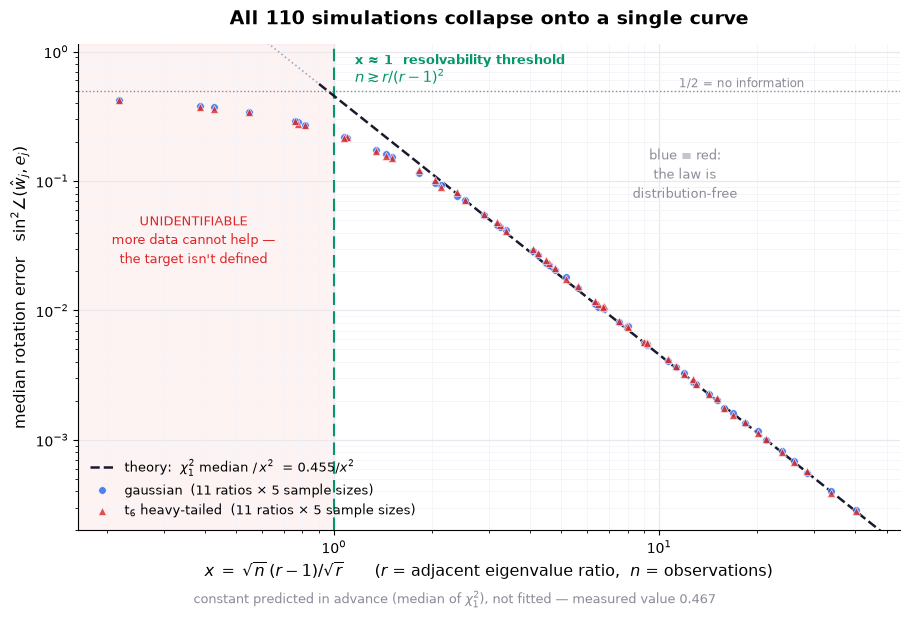

In [9]:
GREY = "#8b8b99"
from scipy.stats import chi2
theory = float(chi2.ppf(0.5, df=1))

fig, ax = plt.subplots(figsize=(9.2, 6.0))

ax.axvspan(coll.x.min() * 0.75, 1.0, color=RED, alpha=0.05, zorder=0)
ax.axvline(1.0, color=GREEN, lw=1.5, ls=(0, (6, 3)), zorder=2)
ax.axhline(0.5, color=GREY, lw=1.0, ls=":", zorder=1)
ax.text(28, 0.53, "1/2 = no information", fontsize=8.6, color=GREY, ha="right")

xg = np.geomspace(0.9, 55, 300)
ax.loglog(xg, theory / xg**2, "--", color=INK, lw=1.8, zorder=4,
          label=rf"theory:  $\chi^2_1$ median $/\,x^2$  = {theory:.3f}$/x^2$")
xg_bad = np.geomspace(coll.x.min() * 0.75, 0.9, 60)
ax.loglog(xg_bad, theory / xg_bad**2, ":", color=INK, lw=1.2, alpha=0.35, zorder=4)

for dist, col, mk, lbl in (("gauss", BLUE, "o", "gaussian"), ("t6", RED, "^", "t$_6$ heavy-tailed")):
    s = coll[coll.dist == dist]
    ax.loglog(s.x, s.q50, mk, ms=5.5, mfc=col, mec="white", mew=0.5,
              alpha=0.8, zorder=5, label=f"{lbl}  (11 ratios × 5 sample sizes)")

ax.set_axisbelow(True)
ax.grid(which="major", color="#e8e8ee", lw=0.9, zorder=0)
ax.grid(which="minor", color="#f4f4f8", lw=0.6, zorder=0)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)

ax.set_xlim(coll.x.min() * 0.75, 55)
ax.set_ylim(2e-4, 1.15)
ax.set_xlabel(r"$x \;=\; \sqrt{n}\,(r-1)/\sqrt{r}$      ($r$ = adjacent eigenvalue ratio,  $n$ = observations)",
              fontsize=11.5)
ax.set_ylabel(r"median rotation error   sin$^2\angle(\hat w_j, e_j)$", fontsize=11.5)
ax.set_title(f"All {len(coll)} simulations collapse onto a single curve",
             fontsize=13.5, fontweight="bold", pad=14)

ax.text(0.37, 0.035, "UNIDENTIFIABLE\nmore data cannot help —\nthe target isn't defined",
        fontsize=9.2, color=RED, ha="center", va="center", linespacing=1.5)
ax.text(1.16, 0.80, "x ≈ 1  resolvability threshold", fontsize=9.6, color=GREEN,
        fontweight="bold", ha="left")
ax.text(1.16, 0.58, r"$n \gtrsim r/(r-1)^2$", fontsize=10.5, color=GREEN, ha="left")

ax.text(12, 0.115, "blue ≡ red:\nthe law is\ndistribution-free", fontsize=9.2,
        color=GREY, ha="center", va="center", linespacing=1.5)

ax.legend(frameon=False, fontsize=9.5, loc="lower left", handlelength=1.8)
fig.text(0.5, -0.015, "constant predicted in advance (median of $\\chi^2_1$), not fitted — "
                      f"measured value {float((coll[coll.x>=4].q50*coll[coll.x>=4].x**2).mean()):.3f}",
         ha="center", fontsize=9.2, color=GREY)
fig.tight_layout()
fig.savefig(OUT_DIR / "ex6_collapse.png", dpi=190, bbox_inches="tight", facecolor="white")
plt.show()

---
## What to write up

Fill these in from your own output once both parts run:

- Part 1: factor 3 median went from ____ (bunched) to ____ (prevalence-fixed), with no volatility changed. The control (`pure-prevalence`) gave ____, i.e. agreeing to within ___%, so $\sigma$ and $c$ are interchangeable through $\lambda=c\sigma^2$.
- Part 2: fitted constant ____ vs the $\chi^2_1$ median 0.4549 — a ___% difference across ___ cells, with the constant *predicted in advance* rather than fitted.
- Sample-size rule: $n \gtrsim r/(r-1)^2$. At $r=1.1$ that is ___ observations; at $r=1.5$, ___.